In [3]:
!pip install seaborn

     -------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
df = sns.load_dataset("titanic")

df.to_csv('titanic.csv',index=False)

print("Dataset loaded and saved successfully.")

Dataset loaded and saved successfully.


In [5]:
print(df.shape)

(891, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_percentage"] > 0
]

display(missing_summary)

,missing_count,missing_percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [9]:
df["age"] = df["age"].fillna(df["age"].median())

In [10]:
df = df.dropna(subset =['embarked']) 

In [11]:
df["deck"] = df["deck"].astype("object").fillna("Unknown")

In [12]:
df.to_csv("titanic.csv", index=False)

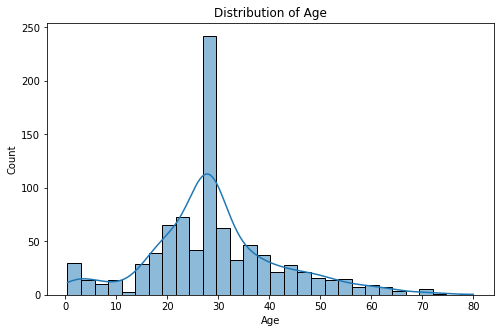

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

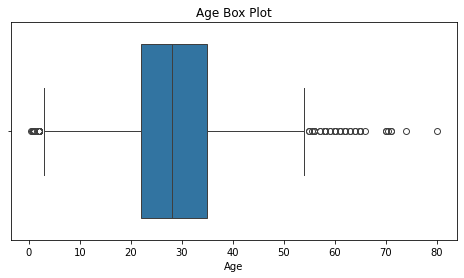

In [14]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["age"])

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.show()

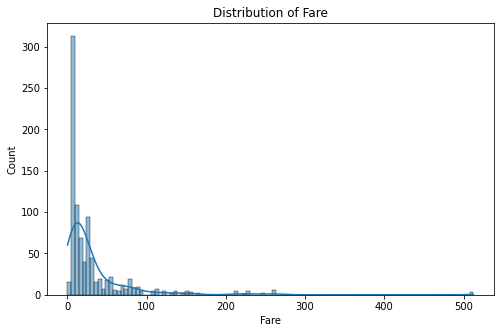

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

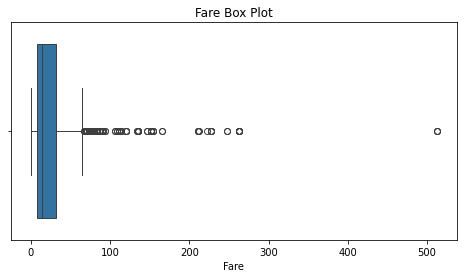

In [16]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["fare"])

plt.title("Fare Box Plot")
plt.xlabel("Fare")

plt.show()

In [17]:
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return q1, q3, iqr, lower_bound, upper_bound, outliers

In [18]:
for column in ["age", "fare"]:
    q1, q3, iqr, lower, upper, outliers = find_iqr_outliers(df[column])

    print(f"\n{column.upper()}")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))


AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of outliers: 114


In [19]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode.tolist())

Mean: 32.09668087739032
Median: 14.4542
Mode: [8.05]


In [20]:
female = df[df["sex"] == "female"]
male = df[df["sex"] == "male"]

female_survival = female["survived"].mean()
male_survival = male["survived"].mean()

print("Female survival rate:", female_survival)
print("Male survival rate:", male_survival)

Female survival rate: 0.7403846153846154
Male survival rate: 0.18890814558058924


In [21]:
first_class = df[df["pclass"] == 1]
second_class = df[df["pclass"] == 2]
third_class = df[df["pclass"] == 3]

print("1st class:", first_class["survived"].mean())
print("2nd class:", second_class["survived"].mean())
print("3rd class:", third_class["survived"].mean())

1st class: 0.6261682242990654
2nd class: 0.47282608695652173
3rd class: 0.24236252545824846


In [22]:
female_first = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

female_second = df[
    (df["sex"] == "female") &
    (df["pclass"] == 2)
]

female_third = df[
    (df["sex"] == "female") &
    (df["pclass"] == 3)
]

male_first = df[
    (df["sex"] == "male") &
    (df["pclass"] == 1)
]

male_second = df[
    (df["sex"] == "male") &
    (df["pclass"] == 2)
]

male_third = df[
    (df["sex"] == "male") &
    (df["pclass"] == 3)
]

In [23]:
sex_class_survival = (
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .reset_index(name="survival_rate")
)

display(sex_class_survival)

,sex,pclass,survival_rate
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


In [28]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


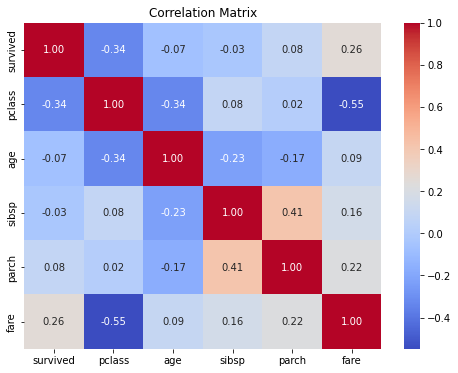

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [30]:
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack()

strongest_two = (
    corr_pairs
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Two strongest correlations:")
display(strongest_two)

Two strongest correlations:


pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64

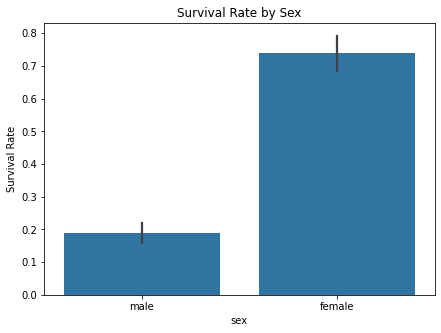

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

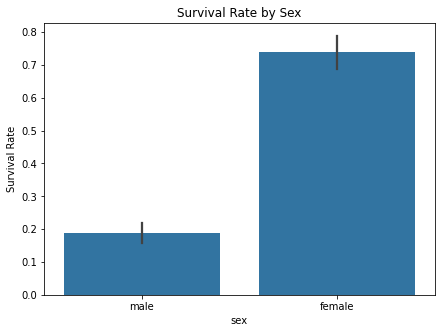

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

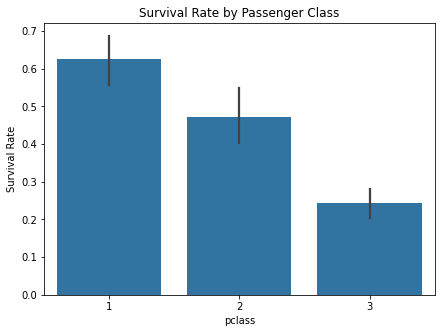

In [33]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

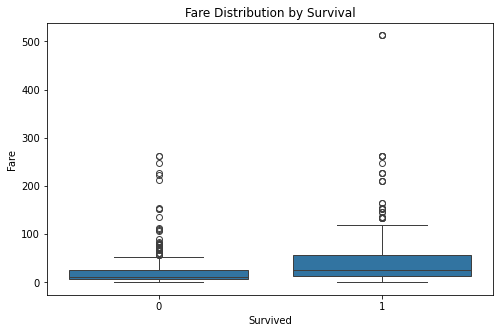

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

In [40]:
!pip install scikit-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 11.2/11.2 MB 2.6 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 3.8 MB/s eta 0:00:00


In [41]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

df_eda_scaled = df.copy()

df_eda_scaled[["age", "fare"]] = scaler.fit_transform(
    df_eda_scaled[["age", "fare"]]
)

In [44]:
print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504


In [45]:
print("\nAfter standardization:")
print(df_eda_scaled[["age", "fare"]].agg(["mean", "std"]))


After standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
